# Customer Churn Analysis

**Problem Statement**

Customer churn directly impacts company revenue. Identifying the key factors that influence churn can help design effective retention strategies.

**Objective**

To analyze customer behavior data and uncover patterns contributing to churn.


In [75]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [76]:
df = pd.read_csv("/content/Customer Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [77]:
df.shape

(7043, 21)

In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [79]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [80]:
df["TotalCharges"].value_counts()

,count
TotalCharges,
,11
20.2,11
19.75,9
20.05,8
19.9,8
...,...
130.15,1
3211.9,1
7843.55,1


In [81]:
#TotalCharges column was converted to numeric type and missing values were handled to ensure data integrity.
df["TotalCharges"] = df["TotalCharges"].replace(" " , "0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [82]:
def convert_values(value):
  if value == 1:
    return "yes"
  else:
    return "no"

df["SeniorCitizen"] =  df["SeniorCitizen"].apply(convert_values)

In [83]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


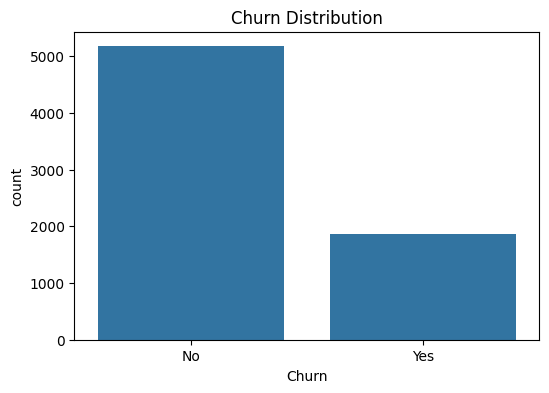

In [84]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Churn Distribution")
plt.show()

Univariate Analysis

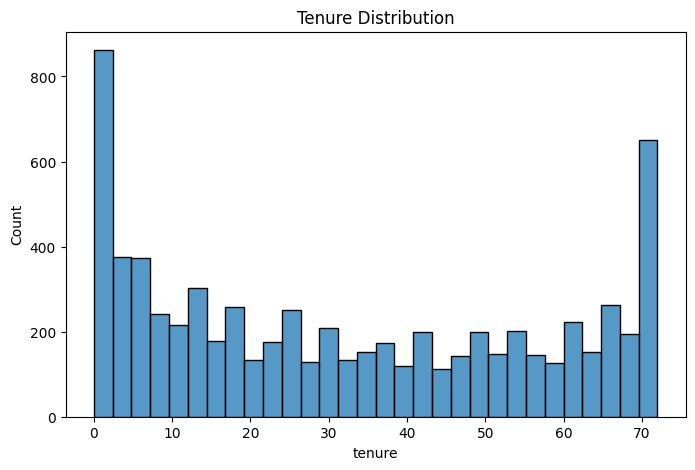

In [85]:
#Tenure distribution
plt.figure(figsize=(8,5))
sns.histplot(df["tenure"], bins=30)
plt.title("Tenure Distribution")
plt.show()

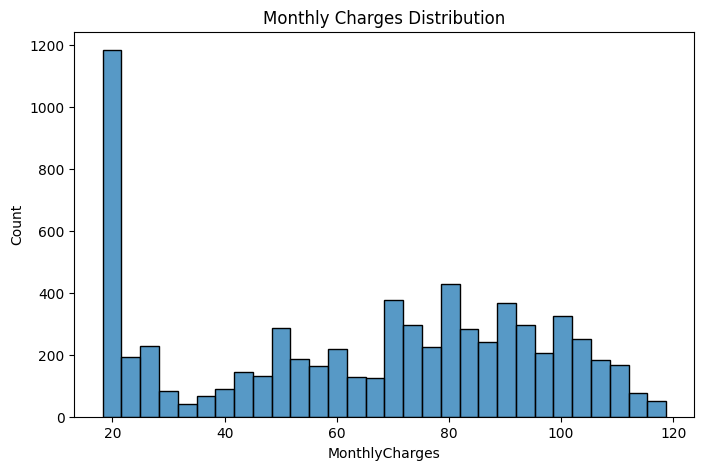

In [86]:
#Monthly charges distribution
plt.figure(figsize=(8,5))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges Distribution")
plt.show()

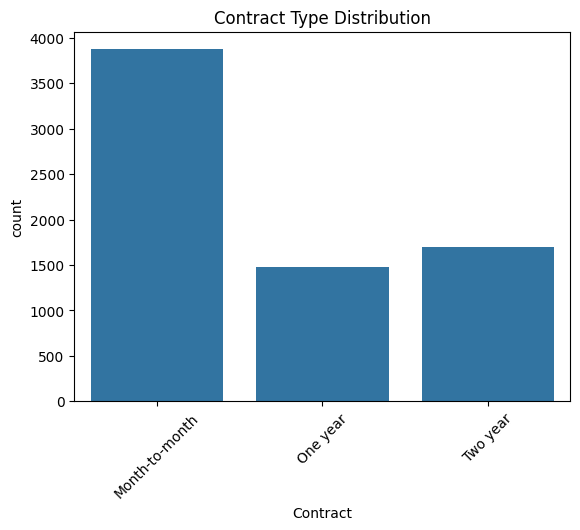

In [87]:
#Contract type distribution
sns.countplot(x="Contract", data=df)
plt.xticks(rotation=45)
plt.title("Contract Type Distribution")
plt.show()

Bivariate analysis

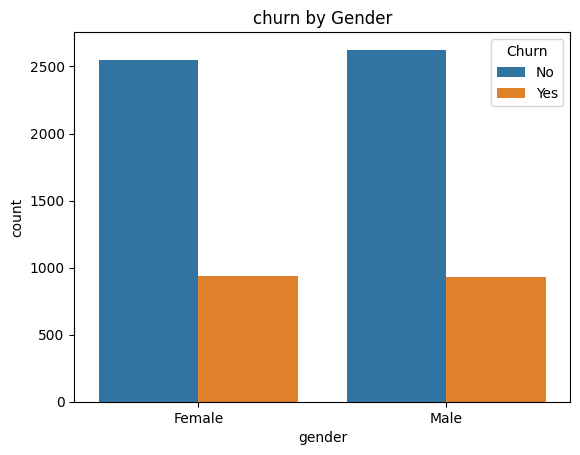

In [88]:
#Gender vs Churn
sns.countplot( x = "gender" , data = df , hue = "Churn"  )
plt.title("churn by Gender")
plt.show()

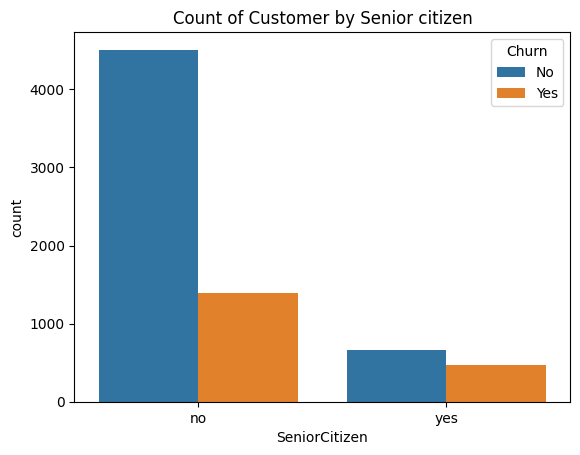

In [89]:
#Senior citizen vs Churn
sns.countplot( x = "SeniorCitizen" , data = df , hue = df["Churn"] )
plt.title("Count of Customer by Senior citizen")
plt.show()

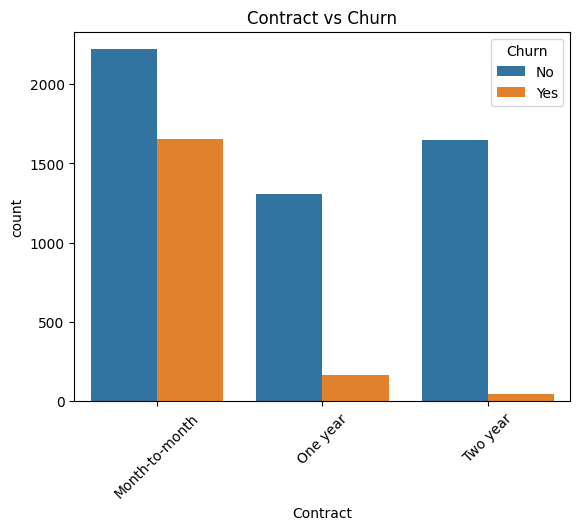

In [90]:
#Contract vs Churn
sns.countplot(x="Contract", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Contract vs Churn")
plt.show()

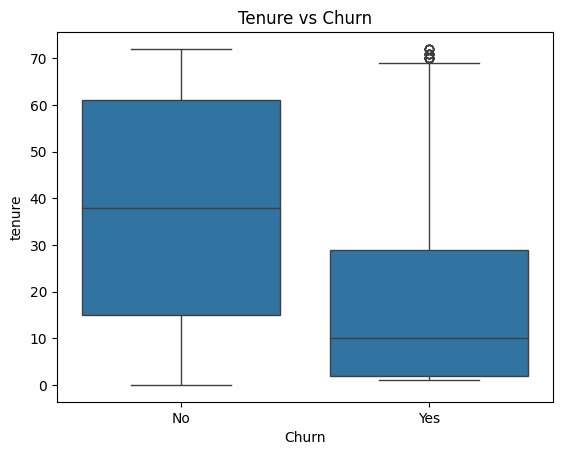

In [91]:
#Tenure vs Churn
sns.boxplot(x="Churn", y="tenure", data=df)
plt.title("Tenure vs Churn")
plt.show()

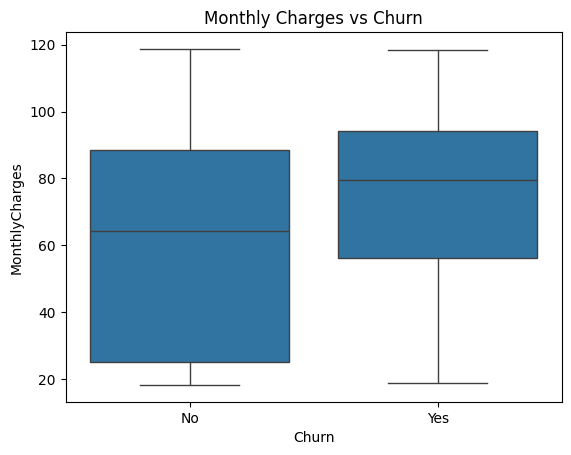

In [92]:
#Monthly Charges vs Churn
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges vs Churn")
plt.show()

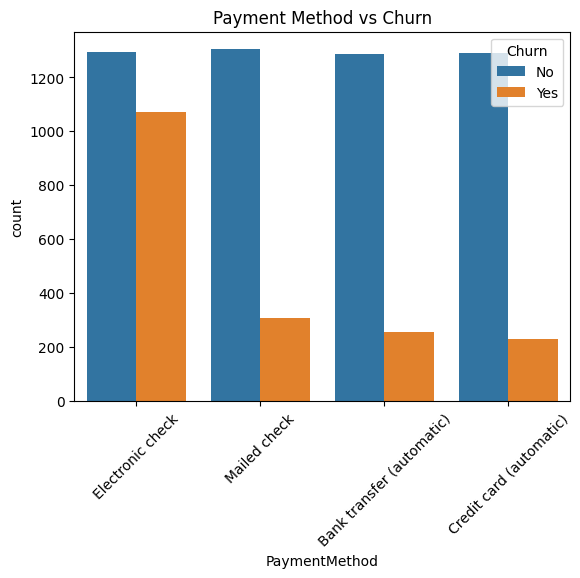

In [93]:
#Payment Method vs Churn
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=45)
plt.title("Payment Method vs Churn")
plt.show()

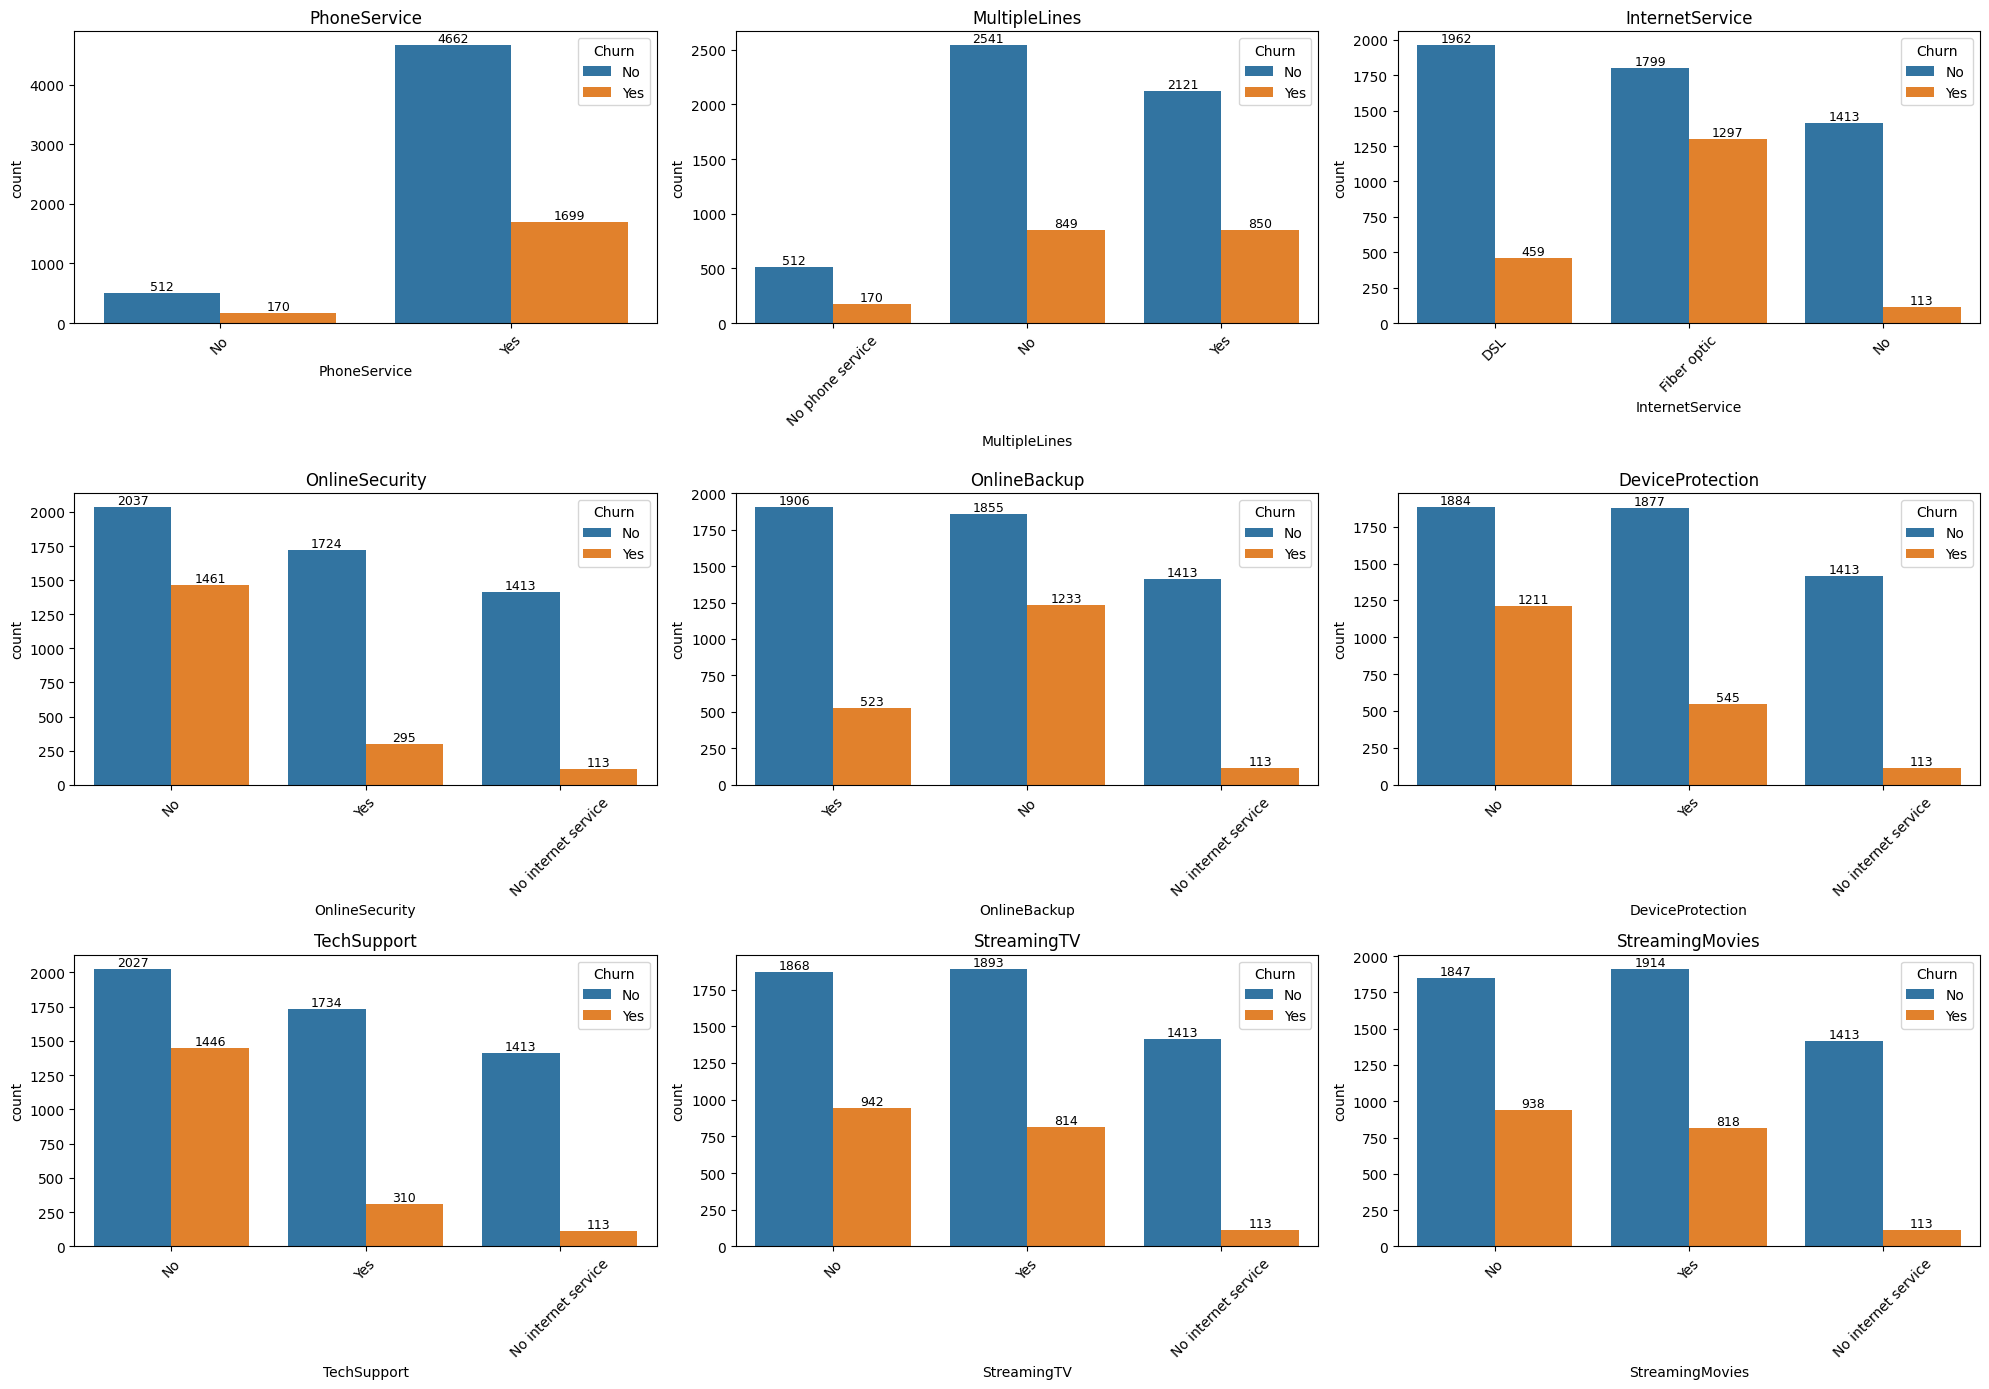

In [94]:
#Service Features vs Churn
columns = [
    'PhoneService', 'MultipleLines', 'InternetService',
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]

plt.figure(figsize=(20, 14))

for i, col in enumerate(columns, 1):
    ax = plt.subplot(3, 3, i)
    sns.countplot(x=col, data=df, hue="Churn", ax=ax)
    ax.set_title(col)
    ax.tick_params(axis='x', rotation=45)

    # Add count labels on bars
    for container in ax.containers:
        ax.bar_label(container, label_type='edge', fontsize=9)

plt.tight_layout()
plt.show()

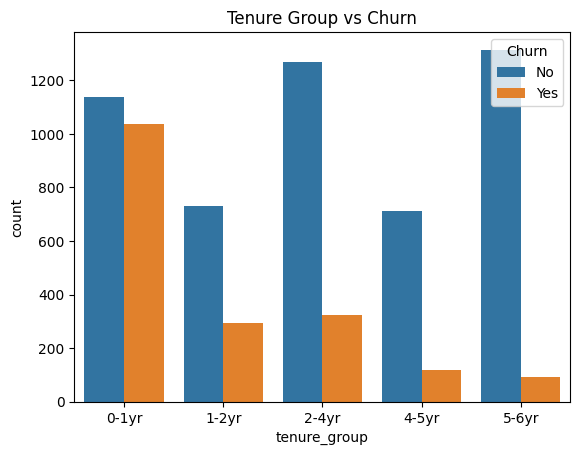

In [95]:
#Tenure Group Analysis
df["tenure_group"] = pd.cut(df["tenure"],
                            bins=[0,12,24,48,60,72],
                            labels=["0-1yr","1-2yr","2-4yr","4-5yr","5-6yr"])

sns.countplot(x="tenure_group", hue="Churn", data=df)
plt.title("Tenure Group vs Churn")
plt.show()

**Key Findings**

1. Customers on month-to-month contracts have the highest churn rate.
2. Customers with low tenure (especially within first 12 months) are more likely to churn.
3. Higher monthly charges are associated with increased churn.
4. Customers using electronic check payment method show higher churn.
5. Customers without value-added services such as OnlineSecurity and TechSupport have higher churn probability.


**Conclusion**

This project successfully identified key churn drivers and provided actionable business insights.
By implementing targeted retention strategies, the company can significantly reduce customer churn and improve long-term revenue stability.

